# 02. PE Graph Topology Visualization
This notebook illustrates the extraction of static features from a test PE file (`putty.exe`) and its subsequent modeling as a graph using PyTorch Geometric and NetworkX.

In [57]:
import sys
from pathlib import Path
project_root = Path.cwd().parent
sys.path.append(str(project_root))

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

print(f"Project root is successfully set to: {project_root}")

from src.features.pe_extractor import PEFeatureExtractor, EmberFeatureParser

import matplotlib.pyplot as plt
import networkx as nx
from src.features.pe_extractor import PEFeatureExtractor
from src.graph.feature_graph import FeatureGraphBuilder

Project root is successfully set to: /home/simone/UNI/Master/Tesi/thesis-project


In [58]:
# Initialize modules
extractor = PEFeatureExtractor()
builder = FeatureGraphBuilder()

sample_path = str(project_root / "data" / "raw" / "test_samples" / "putty.exe")
print(f"Extracting features from: {sample_path}")

# Extraction and building
features = extractor.extract(sample_path)
if features is None:
    print("Error: Unable to parse the PE file. Check the path.")

graph_data = builder.build(features, label=0)
G = builder.to_networkx(graph_data)

print("Graph successfully built in memory.")

Extracting features from: /home/simone/UNI/Master/Tesi/thesis-project/data/raw/test_samples/putty.exe
Graph successfully built in memory.


In [59]:
# Dimensionality check before visualization
print(f"Total nodes: {G.number_of_nodes()}")
print(f"Edges (bidirectional): {G.number_of_edges()}")
print(f"Feature Matrix (X) shape: {graph_data.x.shape}")
print(f"Label (Y): {graph_data.y.item()}")

Total nodes: 9
Edges (bidirectional): 8
Feature Matrix (X) shape: torch.Size([9, 256])
Label (Y): 0


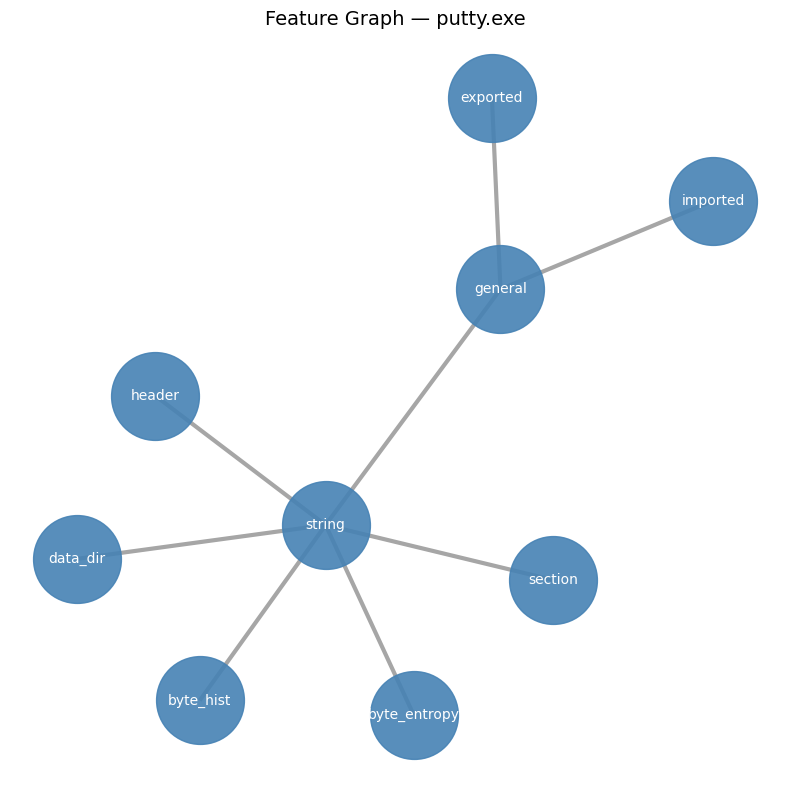

Image saved to: /home/simone/UNI/Master/Tesi/thesis-project/experiments/feature_graph_example.png


In [67]:
fig, ax = plt.subplots(1, 1, figsize=(8, 8))

# nx.spring_layout creates an organic distribution
pos = nx.spring_layout(G, seed=32)
labels = nx.get_node_attributes(G, 'label')

# Rendering nodes, edges, and text
nx.draw_networkx_nodes(G, pos, node_size=4000, node_color='steelblue', alpha=0.9, ax=ax)
nx.draw_networkx_edges(G, pos, width=3, edge_color='gray', alpha=0.7, ax=ax)
nx.draw_networkx_labels(G, pos, labels, font_size=10, font_color='white', ax=ax)

ax.set_title("Feature Graph — putty.exe", fontsize=14)
ax.axis('off')

plt.tight_layout()

# High-resolution save (150 DPI is fine, 300 DPI is print quality)
output_path = str(project_root / "experiments" / "feature_graph_example.png")
plt.savefig(output_path, dpi=150)
plt.show()

print(f"Image saved to: {output_path}")